# 5G network performance tier prediction

**Mini-project:** inspect the supplied 50,000-row dataset, derive a transparent network performance tier, train a classifier, evaluate it on held-out rows, and save the model and training-fitted scaler for the Streamlit app.

**Target disclosure.** `Network Congestion Level` in the source CSV is *not* the target of this project. In an initial held-out check its predictive accuracy was about 34%, near a 33.6% majority-class baseline. The new `Performance Tier` is a deterministic teaching label calculated from five measurements. Consequently, high accuracy below measures how well a model reproduces that scoring rule. It does not validate real-world congestion prediction or network quality against independently measured outcomes.

The original notebook's test report used predictions from the training split after overwriting its first model. Here every reported metric compares `y_test` with predictions for `X_test`; the scaler fits on training rows only.

In [2]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="crest")
DATA_PATH = Path("5g_network_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("5g_performance_mini_project") / "5g_network_data.csv"
assert DATA_PATH.exists(), "Run from the project folder or its parent."
OUTPUT_DIR = DATA_PATH.parent
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.head(3).to_string(index=False))

Dataset shape: (50000, 21)
                 Timestamp      Location  Signal Strength (dBm)  Download Speed (Mbps)  Upload Speed (Mbps)  Latency (ms)  Jitter (ms) Network Type Device Model Carrier Band  Battery Level (%)  Temperature (°C)  Connected Duration (min)  Handover Count  Data Usage (MB)  Video Streaming Quality  VoNR Enabled Network Congestion Level  Ping to Google (ms)  Dropped Connection
2025-05-28 06:59:51.089339 San Francisco                 -108.6                 714.94                60.41          10.0         4.09       5G NSA    iPhone 14    AT&T  n78                 99              35.5                        14               1            97.40                        4         False                     High                 27.9                True
2025-05-28 06:49:51.089353 San Francisco                  -71.5                 686.69               148.70          12.3         1.50           4G      Pixel 7    AT&T n260                 67              22.0             

## 1. Data checks

Inspect feature types, missing values, duplicate rows and the distribution of the source congestion label. Timestamp is retained in the CSV but excluded from modeling; it is not needed for the five-measurement performance rule.

In [4]:
print(df.dtypes.to_string())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nOriginal congestion labels (not the target):")
print(df["Network Congestion Level"].value_counts().to_string())
print("\nFive modeling feature summaries:")
FEATURES = ["Signal Strength (dBm)", "Download Speed (Mbps)", "Upload Speed (Mbps)", "Latency (ms)", "Jitter (ms)"]
print(df[FEATURES].describe().round(2).to_string())

Timestamp                    object
Location                     object
Signal Strength (dBm)       float64
Download Speed (Mbps)       float64
Upload Speed (Mbps)         float64
Latency (ms)                float64
Jitter (ms)                 float64
Network Type                 object
Device Model                 object
Carrier                      object
Band                         object
Battery Level (%)             int64
Temperature (°C)            float64
Connected Duration (min)      int64
Handover Count                int64
Data Usage (MB)             float64
Video Streaming Quality       int64
VoNR Enabled                   bool
Network Congestion Level     object
Ping to Google (ms)         float64
Dropped Connection             bool

Missing values: 0
Duplicate rows: 0

Original congestion labels (not the target):
Network Congestion Level
Low       16791
Medium    16732
High      16477

Five modeling feature summaries:
       Signal Strength (dBm)  Download Speed (Mbps)  U

## 2. Define the derived target

For each row, clip each measurement to a 0–1 component and compute:

`score = 0.30 × download/1000 + 0.15 × upload/150 + 0.25 × (1 − latency/25) + 0.15 × (1 − jitter/5) + 0.15 × (signal + 120)/70`

Each component is individually clipped to `[0, 1]`. Higher throughput and stronger signal increase the score; higher delay and jitter decrease it. These are illustrative fixed thresholds, not a telecom standard or observed ground truth. Label scores below 0.45 as **Limited**, 0.45 to below 0.60 as **Standard**, and 0.60 or above as **Strong**. The rule was fixed before model fitting and uses no test-set statistics.

In [6]:
def performance_score(frame: pd.DataFrame) -> pd.Series:
    c = lambda values: values.clip(0, 1)
    return (
        0.30 * c(frame["Download Speed (Mbps)"] / 1000)
        + 0.15 * c(frame["Upload Speed (Mbps)"] / 150)
        + 0.25 * c(1 - frame["Latency (ms)"] / 25)
        + 0.15 * c(1 - frame["Jitter (ms)"] / 5)
        + 0.15 * c((frame["Signal Strength (dBm)"] + 120) / 70)
    )

df["Performance Score"] = performance_score(df)
df["Performance Tier"] = pd.cut(
    df["Performance Score"],
    bins=[-np.inf, 0.45, 0.60, np.inf],
    labels=["Limited", "Standard", "Strong"],
    right=False,
).astype(str)
print(df["Performance Tier"].value_counts().reindex(["Limited", "Standard", "Strong"]).to_string())
print("\nScore range:", round(df["Performance Score"].min(), 3), "to", round(df["Performance Score"].max(), 3))

Performance Tier
Limited     10840
Standard    23060
Strong      16100

Score range: 0.161 to 0.918


## 3. Exploratory analysis

Visualize class balance, the score distribution, relationships among the five features, and the speed–latency pattern. The source congestion label remains available for comparison but is excluded from all training features.

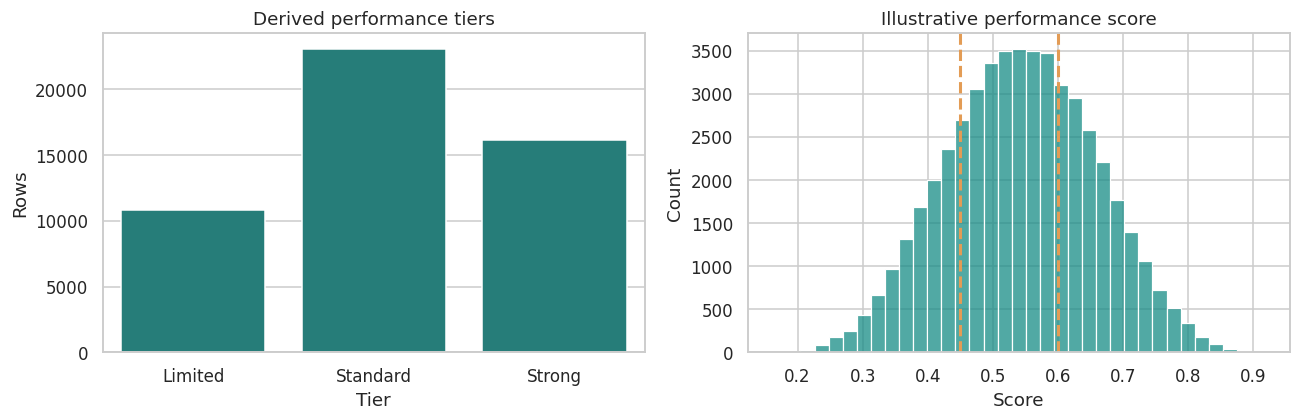

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ["Limited", "Standard", "Strong"]
sns.countplot(data=df, x="Performance Tier", order=order, ax=axes[0], color="#178c86")
axes[0].set(title="Derived performance tiers", xlabel="Tier", ylabel="Rows")
sns.histplot(df["Performance Score"], bins=35, ax=axes[1], color="#178c86")
for boundary in (0.45, 0.60):
    axes[1].axvline(boundary, color="#e39c55", linestyle="--", linewidth=2)
axes[1].set(title="Illustrative performance score", xlabel="Score")
plt.tight_layout()
plt.show()

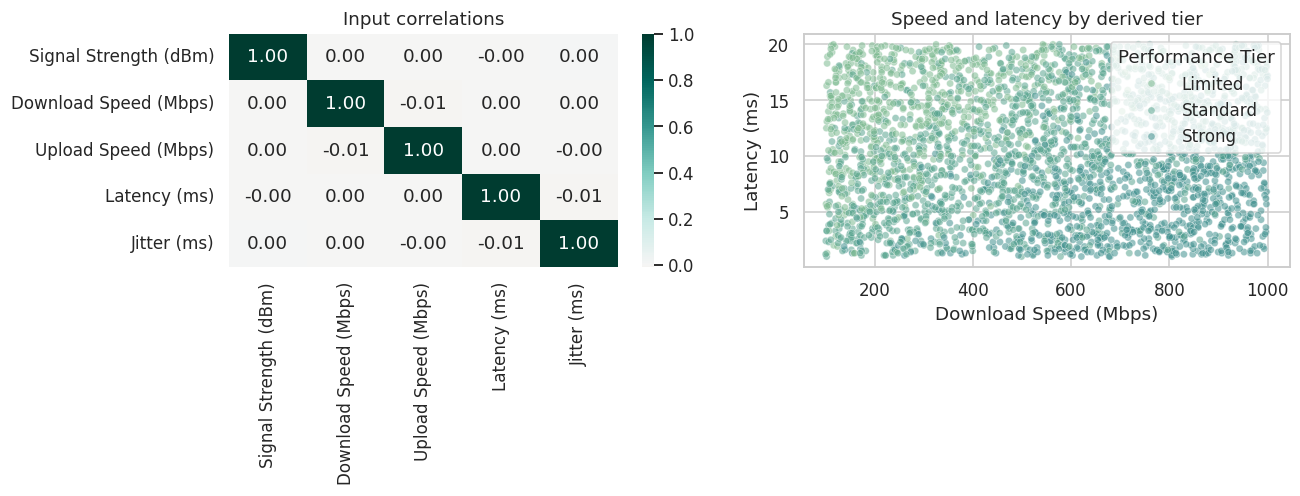

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="BrBG", center=0, ax=axes[0])
axes[0].set_title("Input correlations")
sample = df.sample(n=3000, random_state=42)
sns.scatterplot(data=sample, x="Download Speed (Mbps)", y="Latency (ms)",
                hue="Performance Tier", hue_order=["Limited", "Standard", "Strong"],
                alpha=0.55, s=22, ax=axes[1])
axes[1].set_title("Speed and latency by derived tier")
plt.tight_layout()
plt.show()

## 4. Train/test split and preprocessing

Use a stratified 80/20 split with a fixed seed. Fit `StandardScaler` only on the training inputs, then transform both splits in the same feature order. There are no missing values in the supplied CSV; the code fails clearly if required values become missing rather than silently fabricating measurements.

In [11]:
X = df[FEATURES].copy()
y = df["Performance Tier"].copy()
assert X.notna().all().all() and y.notna().all(), "Missing model values require a documented imputation policy."
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print("Feature order:", list(scaler.feature_names_in_))

Training rows: 40,000; test rows: 10,000
Feature order: ['Signal Strength (dBm)', 'Download Speed (Mbps)', 'Upload Speed (Mbps)', 'Latency (ms)', 'Jitter (ms)']


## 5. Model and baseline

Retain the decision-tree approach in the uploaded notebook but limit depth and leaf size. Compare it with a majority-class baseline on the same unseen test rows. Standard scaling is not required mathematically for a tree, but it provides the requested fitted preprocessing artifact and a consistent app inference contract.

In [13]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train_scaled, y_train)
model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
baseline_pred = baseline.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Majority baseline accuracy: {baseline_accuracy:.4f}")
print(f"Decision tree test accuracy: {test_accuracy:.4f}")
print(f"Decision tree balanced accuracy: {test_balanced_accuracy:.4f}")
print("\nHeld-out classification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
assert test_accuracy > 0.70, "The held-out accuracy did not meet the requested threshold."


Majority baseline accuracy: 0.4612
Decision tree test accuracy: 0.8445
Decision tree balanced accuracy: 0.8421

Held-out classification report:
              precision    recall  f1-score   support

     Limited     0.8462    0.8224    0.8342      2168
    Standard     0.8228    0.8448    0.8336      4612
      Strong     0.8759    0.8590    0.8674      3220

    accuracy                         0.8445     10000
   macro avg     0.8483    0.8421    0.8450     10000
weighted avg     0.8450    0.8445    0.8446     10000



              Feature  Importance
Download Speed (Mbps)      0.3488
         Latency (ms)      0.2408
  Upload Speed (Mbps)      0.1521
          Jitter (ms)      0.1464
Signal Strength (dBm)      0.1119


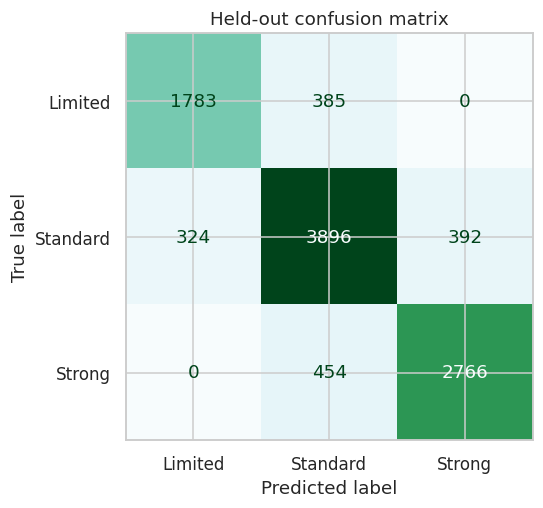

In [14]:
labels = ["Limited", "Standard", "Strong"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="BuGn", values_format="d", colorbar=False
)
plt.title("Held-out confusion matrix")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"Feature": FEATURES, "Importance": model.feature_importances_})
      .sort_values("Importance", ascending=False).round(4).to_string(index=False))

## 6. Save and reload artifacts

The Streamlit app loads `model.pkl` and `scaler.pkl` via joblib, reads the exact model feature order from the fitted scaler, then transforms a one-row DataFrame. `metrics.json` records the target definition and held-out result for transparent reuse. Only load `.pkl` files from a source you trust.

In [16]:
joblib.dump(model, OUTPUT_DIR / "model.pkl")
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")
metrics = {
    "target": "Performance Tier (derived from five input measurements)",
    "target_type": "deterministic illustrative rule, not independently measured ground truth",
    "features": FEATURES,
    "score_weights": {"download": 0.30, "upload": 0.15, "latency": 0.25, "jitter": 0.15, "signal": 0.15},
    "thresholds": {"limited_below": 0.45, "strong_at_or_above": 0.60},
    "split": {"train_rows": len(X_train), "test_rows": len(X_test), "test_fraction": 0.2, "stratified": True, "random_state": 42},
    "model": "DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)",
    "baseline_accuracy": round(float(baseline_accuracy), 6),
    "test_accuracy": round(float(test_accuracy), 6),
    "balanced_accuracy": round(float(test_balanced_accuracy), 6),
    "class_counts": {k: int(v) for k, v in y.value_counts().items()},
    "confusion_labels": labels,
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    "feature_importances": {name: float(importance) for name, importance in zip(FEATURES, model.feature_importances_)},
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
loaded_model = joblib.load(OUTPUT_DIR / "model.pkl")
loaded_scaler = joblib.load(OUTPUT_DIR / "scaler.pkl")
assert np.array_equal(y_pred[:10], loaded_model.predict(loaded_scaler.transform(X_test.iloc[:10])))
print("Saved model.pkl, scaler.pkl and metrics.json. Reloaded predictions match.")

Saved model.pkl, scaler.pkl and metrics.json. Reloaded predictions match.


## Interpretation

The test accuracy reflects replication of the disclosed five-feature scoring formula on unseen rows. Because the target itself is computed from those same inputs, this cannot establish external predictive validity. To predict real congestion or service quality, gather independently measured labels and repeat the held-out evaluation. No test labels were used for scaler fitting or model training.